In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammedabdeldayem/the-fake-or-real-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset


In [2]:
import os, hashlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Audio
import librosa

# ML
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not found – will skip that model. Install with: pip install xgboost")

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout, Flatten,
    BatchNormalization, GlobalAveragePooling1D,
    Input, Bidirectional, LSTM
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy version      : {np.__version__}")
print("✅ All imports successful!")

2026-06-11 06:22:52.913456: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781158973.416539      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781158973.568884      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781158974.569905      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781158974.569954      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781158974.569957      58 computation_placer.cc:177] computation placer alr

TensorFlow version : 2.19.0
GPU available      : True
NumPy version      : 2.4.6
✅ All imports successful!


In [3]:
# ── Dataset Paths ─────────────────────────────────────────────
# Adjust BASE_DIR to point to your downloaded FoR dataset.
# Expected layout:
#   BASE_DIR/
#     training/real/   training/fake/
#     validation/real/ validation/fake/
#     testing/real/    testing/fake/
BASE_DIR = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm"
# If running locally, e.g.:
# BASE_DIR = "./data/for-norm"

CFG = dict(
    # ── paths ──────────────────────────────────────────────────
    train_dir   = os.path.join(BASE_DIR, "training"),
    val_dir     = os.path.join(BASE_DIR, "validation"),
    test_dir    = os.path.join(BASE_DIR, "testing"),
    output_dir  = "./outputs",        # models, plots, reports saved here

    # ── audio ──────────────────────────────────────────────────
    sr          = 16_000,               # resample rate (Hz)
    duration    = 3,                    # clip length (seconds)
    # → samples per clip = sr * duration = 48 000

    # ── feature extraction ─────────────────────────────────────
    n_mfcc      = 40,                   # MFCC coefficients
    n_lfcc      = 40,                   # LFCC coefficients (mirror of MFCC with linear filterbank)
    n_fft       = 512,
    hop_length  = 160,                  # 10 ms hop at 16 kHz
    win_length  = 400,                  # 25 ms window

    # ── ML baseline ────────────────────────────────────────────
    ml_random_state = 42,

    # ── Deep Learning ──────────────────────────────────────────
    dl_epochs       = 50,
    dl_batch_size   = 32,
    dl_lr           = 1e-3,
    dl_patience     = 10,               # early stopping patience

    # ── labels ─────────────────────────────────────────────────
    label_map   = {"real": 0, "fake": 1},
    class_names = ["Genuine", "Deepfake"],
)

# Derived
CFG["n_samples"] = CFG["sr"] * CFG["duration"]

os.makedirs(CFG["output_dir"], exist_ok=True)
print("✅ Configuration set.")
print(f"   Samples per clip : {CFG['n_samples']:,}")
print(f"   Output directory : {CFG['output_dir']}")

✅ Configuration set.
   Samples per clip : 48,000
   Output directory : ./outputs


In [4]:
import soundfile as sf      # add this line

def md5_hash(path: str) -> str:
    """Fast MD5 of a file for de-duplication."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(65536), b""):
            h.update(chunk)
    return h.hexdigest()

def get_hash_set(folder):
    hashes = set()

    for root, _, files in os.walk(folder):
        for f in files:
            if f.endswith(".wav"):
                hashes.add(md5_hash(os.path.join(root, f)))

    return hashes
    
def load_audio(path: str, sr: int = 16_000, n_samples: int = 48_000) -> np.ndarray | None:
    try:
        y, file_sr = sf.read(path, dtype="float32", always_2d=False)
        if y.ndim > 1:
            y = y.mean(axis=1)                              # stereo → mono (rare in for-norm)
        if file_sr != sr:                                   # for-norm is already 16 kHz, skips this
            y = librosa.resample(y, orig_sr=file_sr, target_sr=sr)
        if len(y) < n_samples:
            y = np.pad(y, (0, n_samples - len(y)))
        else:
            y = y[:n_samples]
        return y.astype(np.float32)
    except Exception:
        return None


from concurrent.futures import ThreadPoolExecutor

def load_dataset(base_path: str, cfg: dict, desc: str = "Loading",
                 n_workers: int = 4) -> tuple[list, list]:
    file_jobs  = []                 # list of (fpath, label)
    # seen_names: set = set()
    skipped = {"zero_byte": 0, "duplicate": 0, "corrupt": 0}

    for class_name, label in cfg["label_map"].items():
        seen_names: set = set()
        class_dir = os.path.join(base_path, class_name)
        if not os.path.isdir(class_dir):
            print(f"  ⚠️  Directory not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if not fname.endswith((".wav", ".flac", ".mp3")):
                continue
            fpath = os.path.join(class_dir, fname)
            if os.path.getsize(fpath) == 0:
                skipped["zero_byte"] += 1; continue
            if fname in seen_names:                         # filename dedup (fast)
                skipped["duplicate"] += 1; continue
            seen_names.add(fname)
            file_jobs.append((fpath, label))

    def _load(job):
        fpath, label = job
        return load_audio(fpath, sr=cfg["sr"], n_samples=cfg["n_samples"]), label

    audio_list, label_list = [], []
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        for y, label in tqdm(pool.map(_load, file_jobs),
                             total=len(file_jobs), desc=desc):
            if y is None:
                skipped["corrupt"] += 1
            else:
                audio_list.append(y)
                label_list.append(label)

    real_n = label_list.count(0)
    fake_n = label_list.count(1)
    print(f"  ✅ Loaded {len(audio_list)} files  (Genuine={real_n}, Deepfake={fake_n})")
    print(f"     Skipped → zero-byte:{skipped['zero_byte']}  "
          f"duplicate:{skipped['duplicate']}  corrupt:{skipped['corrupt']}")
    return audio_list, label_list

print("Loading training set ...")
train_audio, train_labels = load_dataset(CFG["train_dir"],   CFG, "Train")
print("\nLoading validation set ...")
val_audio,   val_labels   = load_dataset(CFG["val_dir"],     CFG, "Val")
print("\nLoading test set ...")
test_audio,  test_labels  = load_dataset(CFG["test_dir"],    CFG, "Test")




# train_hashes = get_hash_set(CFG["train_dir"])
# val_hashes   = get_hash_set(CFG["val_dir"])
# test_hashes  = get_hash_set(CFG["test_dir"])

# print("Train-Test overlap:", len(train_hashes & test_hashes))
# print("Val-Test overlap:", len(   val_hashes & test_hashes))
# print("Val-Train overlap:", len(val_hashes & train_hashes))
 

Loading training set ...


Train: 100%|██████████| 53868/53868 [02:47<00:00, 321.24it/s]


  ✅ Loaded 53868 files  (Genuine=26941, Deepfake=26927)
     Skipped → zero-byte:0  duplicate:0  corrupt:0

Loading validation set ...


Val: 100%|██████████| 10798/10798 [00:33<00:00, 324.79it/s]


  ✅ Loaded 10798 files  (Genuine=5400, Deepfake=5398)
     Skipped → zero-byte:0  duplicate:0  corrupt:0

Loading test set ...


Test: 100%|██████████| 4634/4634 [00:11<00:00, 405.64it/s]


  ✅ Loaded 4634 files  (Genuine=2264, Deepfake=2370)
     Skipped → zero-byte:0  duplicate:0  corrupt:0
Train-Test overlap: 0
Val-Test overlap: 0
Val-Train overlap: 0


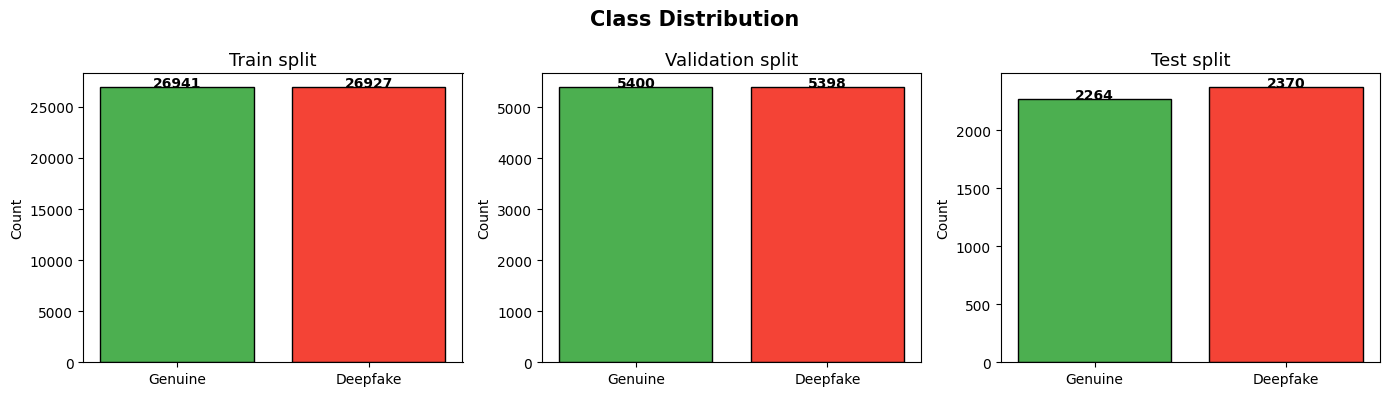

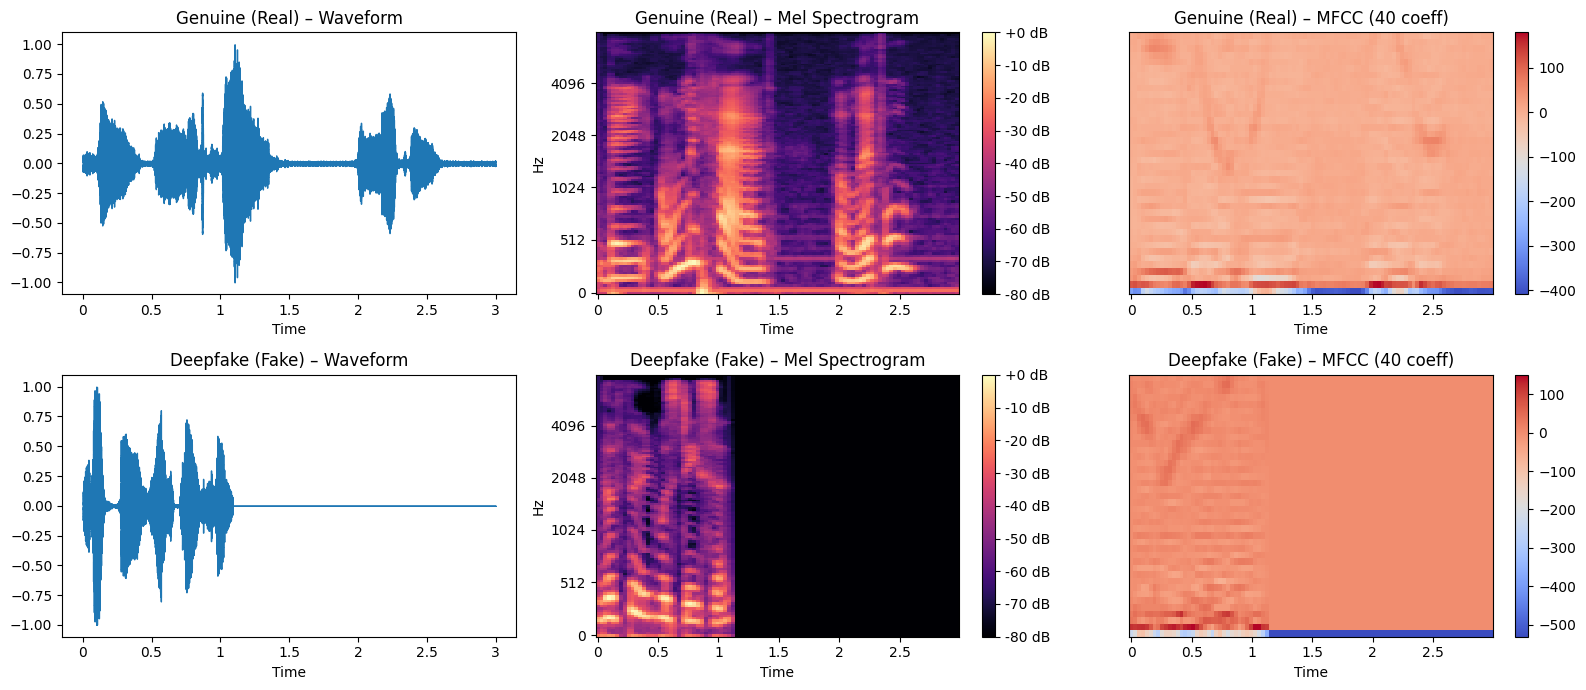

✅ EDA plots saved.


In [5]:
# ── Class distribution ────────────────────────────────────────
def plot_class_distribution(labels_dict: dict, class_names: list):
    fig, axes = plt.subplots(1, len(labels_dict), figsize=(14, 4))
    for ax, (split_name, labels) in zip(axes, labels_dict.items()):
        counts = [labels.count(i) for i in range(len(class_names))]
        bars = ax.bar(class_names, counts, color=["#4CAF50", "#F44336"], edgecolor="black")
        ax.set_title(f"{split_name} split", fontsize=13)
        ax.set_ylabel("Count")
        for bar, c in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(c), ha="center", fontweight="bold")
    plt.suptitle("Class Distribution", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "class_distribution.png"), dpi=150, bbox_inches="tight")
    plt.show()

plot_class_distribution(
    {"Train": train_labels, "Validation": val_labels, "Test": test_labels},
    CFG["class_names"]
)

# ── Waveform + spectrogram for one real & one fake clip ───────
def plot_sample_analysis(audio_real, audio_fake, sr: int):
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    pairs = [("Genuine (Real)", audio_real, axes[0]),
             ("Deepfake (Fake)", audio_fake, axes[1])]

    for title, y, row_axes in pairs:
        # Waveform
        librosa.display.waveshow(y, sr=sr, ax=row_axes[0])
        row_axes[0].set_title(f"{title} – Waveform")

        # Log-Mel spectrogram
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", ax=row_axes[1])
        row_axes[1].set_title(f"{title} – Mel Spectrogram")
        fig.colorbar(row_axes[1].collections[0], ax=row_axes[1], format="%+2.0f dB")

        # MFCC
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=CFG["n_mfcc"])
        librosa.display.specshow(mfcc, sr=sr, x_axis="time", ax=row_axes[2])
        row_axes[2].set_title(f"{title} – MFCC ({CFG['n_mfcc']} coeff)")
        fig.colorbar(row_axes[2].collections[0], ax=row_axes[2])

    plt.tight_layout()
    plt.savefig(os.path.join(CFG["output_dir"], "sample_analysis.png"), dpi=150, bbox_inches="tight")
    plt.show()

# Pick one sample from each class
real_sample = train_audio[train_labels.index(0)]
fake_sample = train_audio[train_labels.index(1)]
plot_sample_analysis(real_sample, fake_sample, CFG["sr"])
print("✅ EDA plots saved.")


In [6]:
# ── Hand-crafted feature vector (for ML baseline) ─────────────
from scipy.fftpack import dct
def compute_lfcc(y: np.ndarray, sr: int, n_lfcc: int = 40,
                 n_fft: int = 512, hop_length: int = 160) -> np.ndarray:
    """
    Linear-Frequency Cepstral Coefficients.
    Librosa doesn't provide LFCC natively, so we build a linear filterbank.
    """
    # Build linear filterbank
    n_filters = n_lfcc * 2
    freqs = np.linspace(0, sr / 2, n_fft // 2 + 1)
    filter_edges = np.linspace(0, sr / 2, n_filters + 2)
    fb = np.zeros((n_filters, n_fft // 2 + 1))
    for m in range(1, n_filters + 1):
        f_m_minus = filter_edges[m - 1]
        f_m       = filter_edges[m]
        f_m_plus  = filter_edges[m + 1]
        for k, f in enumerate(freqs):
            if f_m_minus <= f <= f_m:
                fb[m - 1, k] = (f - f_m_minus) / (f_m - f_m_minus)
            elif f_m < f <= f_m_plus:
                fb[m - 1, k] = (f_m_plus - f) / (f_m_plus - f_m)

    # STFT magnitude
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
    # Apply filterbank
    filtered = np.dot(fb, S)  # (n_filters, T)
    filtered = np.where(filtered == 0, np.finfo(float).eps, filtered)
    log_filtered = np.log(filtered)
    # DCT → LFCC
# Replace the last two lines of compute_lfcc with:
    lfcc = dct(log_filtered, type=2, axis=0, norm="ortho")[:n_lfcc, :]
    return lfcc


def extract_feature_vector(y: np.ndarray, cfg: dict) -> np.ndarray:
    """
    Extract a 1D feature vector from a raw waveform.
    Used for ML baseline.
    """
    sr          = cfg["sr"]
    n_mfcc      = cfg["n_mfcc"]
    n_fft       = cfg["n_fft"]
    hop_length  = cfg["hop_length"]

    # 1. MFCC
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc,
                                  n_fft=n_fft, hop_length=hop_length)
    mfcc_mean = np.mean(mfcc, axis=1)    # (n_mfcc,)
    mfcc_std  = np.std(mfcc,  axis=1)    # (n_mfcc,)

    # 2. Delta-MFCC (velocity)
    delta_mfcc = librosa.feature.delta(mfcc)
    delta_mean = np.mean(delta_mfcc, axis=1)  # (n_mfcc,)

    # 3. LFCC (simplified linear cepstrum)
    lfcc = compute_lfcc(y, sr, n_lfcc=cfg["n_lfcc"], n_fft=n_fft, hop_length=hop_length)
    lfcc_mean = np.mean(lfcc, axis=1)
    lfcc_std  = np.std(lfcc,  axis=1)

    # 4. Spectral features
    sc   = librosa.feature.spectral_centroid(y=y,  sr=sr, n_fft=n_fft, hop_length=hop_length)
    sr_f = librosa.feature.spectral_rolloff(y=y,   sr=sr, n_fft=n_fft, hop_length=hop_length)
    zcr  = librosa.feature.zero_crossing_rate(y,           hop_length=hop_length)

    spectral = np.array([
        np.mean(sc),  np.std(sc),
        np.mean(sr_f), np.std(sr_f),
        np.mean(zcr), np.std(zcr),
    ])

    return np.concatenate([mfcc_mean, mfcc_std, delta_mean,
                           lfcc_mean, lfcc_std, spectral])


def extract_mfcc_sequence(y: np.ndarray, cfg: dict, T: int = 96) -> np.ndarray:
    """
    Extract a 2D MFCC time-series of fixed shape (n_mfcc, T).
    Used for the 1D-CNN deep learning model.
    """
    mfcc = librosa.feature.mfcc(y=y, sr=cfg["sr"], n_mfcc=cfg["n_mfcc"],
                                  n_fft=cfg["n_fft"], hop_length=cfg["hop_length"])
    # Normalise per utterance
    mfcc = (mfcc - mfcc.mean()) / (mfcc.std() + 1e-9)
    # Pad / trim time axis to T
    if mfcc.shape[1] < T:
        mfcc = np.pad(mfcc, ((0, 0), (0, T - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :T]
    return mfcc.astype(np.float32)   # (n_mfcc, T)


# ── Extract for all splits ─────────────────────────────────────
print("Extracting ML feature vectors ...")

def batch_extract_vectors(audio_list, cfg):
    return np.array([extract_feature_vector(y, cfg)
                     for y in tqdm(audio_list, desc="  Feature vectors")])

X_train_ml = batch_extract_vectors(train_audio, CFG)
X_val_ml   = batch_extract_vectors(val_audio,   CFG)
X_test_ml  = batch_extract_vectors(test_audio,  CFG)

y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print(f"\nML feature shapes:")
print(f"  Train : {X_train_ml.shape}  labels: {y_train.shape}")
print(f"  Val   : {X_val_ml.shape}  labels: {y_val.shape}")
print(f"  Test  : {X_test_ml.shape}  labels: {y_test.shape}")

# ── Normalise ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_ml_s = scaler.fit_transform(X_train_ml)
X_val_ml_s   = scaler.transform(X_val_ml)
X_test_ml_s  = scaler.transform(X_test_ml)

joblib.dump(scaler, os.path.join(CFG["output_dir"], "feature_scaler.pkl"))
print("✅ Scaler saved.")

Extracting ML feature vectors ...


  Feature vectors: 100%|██████████| 4634/4634 [02:06<00:00, 36.69it/s]



ML feature shapes:
  Train : (53868, 206)  labels: (53868,)
  Val   : (10798, 206)  labels: (10798,)
  Test  : (4634, 206)  labels: (4634,)
✅ Scaler saved.


In [7]:
# ── ADD THIS as line 1 of that cell ────────────────────────────
def compute_eer(y_true: np.ndarray, y_score: np.ndarray) -> tuple[float, float]:
    """
    Compute Equal Error Rate and the corresponding threshold.
    y_true  : 0 = genuine, 1 = fake
    y_score : probability of being fake (class 1)
    Returns (eer_percent, threshold).
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1.0 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    return float(eer * 100), float(thresholds[idx])


def full_evaluation(y_true: np.ndarray, y_pred: np.ndarray,
                    y_score: np.ndarray, class_names: list,
                    model_name: str, output_dir: str) -> dict:
    """
    Compute + print all required metrics.
    Saves confusion matrix and ROC curve plots.
    Returns a metrics dictionary.
    """
    acc      = accuracy_score(y_true, y_pred) * 100
    f1       = f1_score(y_true, y_pred, average="binary") * 100
    eer, thr = compute_eer(y_true, y_score)
    report   = classification_report(y_true, y_pred,
                                     target_names=class_names, output_dict=True)

    per_class_acc = {}
    for i, cname in enumerate(class_names):
        mask = y_true == i
        per_class_acc[cname] = accuracy_score(y_true[mask], y_pred[mask]) * 100

    roc_auc = auc(*roc_curve(y_true, y_score)[:2])

    # ── Print summary ──────────────────────────────────────────
    print(f"\n{'='*55}")
    print(f"  {model_name}  – Evaluation Summary")
    print(f"{'='*55}")
    print(f"  Overall Accuracy      : {acc:.2f}%  (need ≥ 80%)")
    print(f"  F1 Score (binary)     : {f1:.2f}%  (need ≥ 80%)")
    print(f"  EER                   : {eer:.2f}%  (need ≤ 12%)")
    print(f"  EER threshold         : {thr:.4f}")
    print(f"  ROC-AUC               : {roc_auc:.4f}")
    for cname, pacc in per_class_acc.items():
        flag = "✅" if pacc >= 75 else "❌"
        print(f"  Per-class [{cname:9s}]: {pacc:.2f}%  {flag} (need ≥ 75%)")
    print()
    # Status flags
    print(f"  [Acc ≥ 80%]  {'✅ PASS' if acc  >= 80 else '❌ FAIL'}")
    print(f"  [EER ≤ 12%]  {'✅ PASS' if eer  <= 12 else '❌ FAIL'}")
    print(f"  [F1  ≥ 80%]  {'✅ PASS' if f1   >= 80 else '❌ FAIL'}")
    print(f"{'='*55}")

    # ── Confusion Matrix ───────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{model_name} – Confusion Matrix", fontsize=13)

    # ROC curve
    fpr_r, tpr_r, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr_r, tpr_r, color="#E74C3C", lw=2,
                 label=f"ROC (AUC = {roc_auc:.3f})")
    axes[1].plot([0,1],[0,1],"k--", lw=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{model_name} – ROC Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{model_name.replace(' ','_')}_evaluation.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {save_path}")

    return dict(model=model_name, accuracy=acc, f1=f1, eer=eer,
                roc_auc=roc_auc, **{f"acc_{k}":v for k,v in per_class_acc.items()},
                threshold=thr)

print("✅ Metric helpers ready.")

✅ Metric helpers ready.



Training RandomForest ...

  RandomForest [val]  – Evaluation Summary
  Overall Accuracy      : 99.74%  (need ≥ 80%)
  F1 Score (binary)     : 99.74%  (need ≥ 80%)
  EER                   : 0.19%  (need ≤ 12%)
  EER threshold         : 0.6133
  ROC-AUC               : 1.0000
  Per-class [Genuine  ]: 99.54%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 99.94%  ✅ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


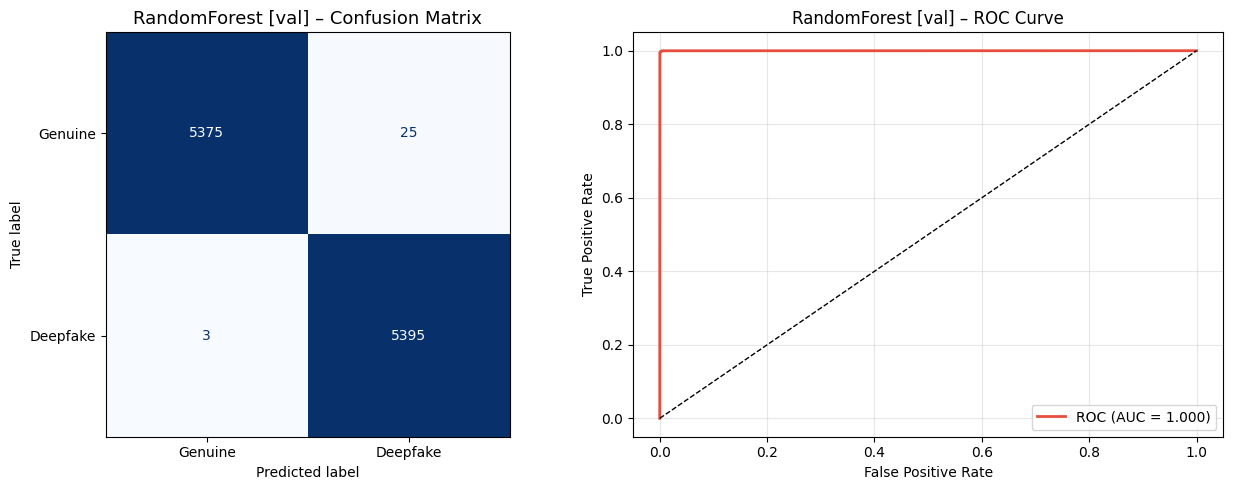

  Saved: ./outputs/RandomForest_[val]_evaluation.png
  💾 Saved → ./outputs/RandomForest_model.pkl

Training XGBoost ...

  XGBoost [val]  – Evaluation Summary
  Overall Accuracy      : 99.82%  (need ≥ 80%)
  F1 Score (binary)     : 99.82%  (need ≥ 80%)
  EER                   : 0.13%  (need ≤ 12%)
  EER threshold         : 0.6500
  ROC-AUC               : 1.0000
  Per-class [Genuine  ]: 99.74%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 99.91%  ✅ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


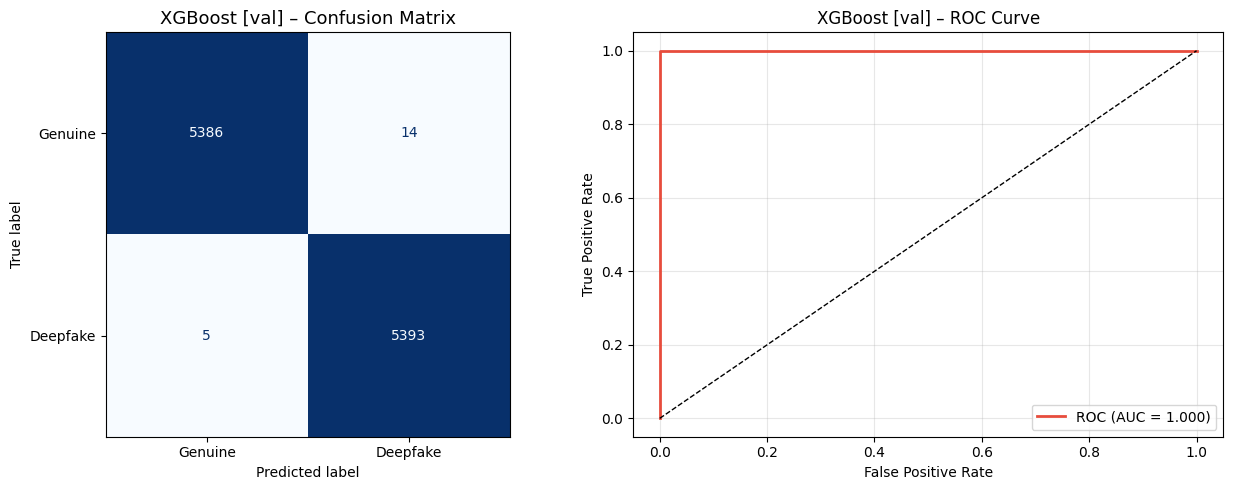

  Saved: ./outputs/XGBoost_[val]_evaluation.png
  💾 Saved → ./outputs/XGBoost_model.pkl

📋 ML Baseline Results Summary:


,accuracy,f1,eer,roc_auc
model,,,,
RandomForest [val],99.74,99.74,0.19,1.0
XGBoost [val],99.82,99.82,0.13,1.0


In [9]:
   # REPLACE the full ml_models block with this:

all_metrics = []   # explicit reset — prevents stale results on re-run

ml_models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=None, n_jobs=-1,     random_state=CFG["ml_random_state"]
    ),
    # "GradientBoosting": GradientBoostingClassifier(
    #     n_estimators=200, max_depth=5, learning_rate=0.1,
    #     subsample=0.8, random_state=CFG["ml_random_state"]
    # ),
}
if HAS_XGB:
    ml_models["XGBoost"] = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        tree_method="hist", device="cuda",
        random_state=CFG["ml_random_state"], n_jobs=-1
    )


# ── Train & Evaluate ───────────────────────────────────────────
for name, model in ml_models.items():
    print(f"\nTraining {name} ...")
    model.fit(X_train_ml_s, y_train)

    # Select & tune using val set only
    y_pred_val  = model.predict(X_val_ml_s)
    y_score_val = model.predict_proba(X_val_ml_s)[:, 1]
    metrics = full_evaluation(y_val, y_pred_val, y_score_val,
                              CFG["class_names"], f"{name} [val]", CFG["output_dir"])
    all_metrics.append(metrics)

    # Save model
    save_path = os.path.join(CFG["output_dir"], f"{name.replace(' ','_')}_model.pkl")
    joblib.dump(model, save_path)
    print(f"  💾 Saved → {save_path}")

# ── Summary table ─────────────────────────────────────────────}─
results_df = pd.DataFrame(all_metrics).set_index("model")
print("\n📋 ML Baseline Results Summary:")
display(results_df[["accuracy","f1","eer","roc_auc"]].round(2))

Best ML model on val: XGBoost → evaluating on test set

  XGBoost [test]  – Evaluation Summary
  Overall Accuracy      : 50.22%  (need ≥ 80%)
  F1 Score (binary)     : 5.26%  (need ≥ 80%)
  EER                   : 21.34%  (need ≤ 12%)
  EER threshold         : 0.0003
  ROC-AUC               : 0.8583
  Per-class [Genuine  ]: 99.96%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 2.70%  ❌ (need ≥ 75%)

  [Acc ≥ 80%]  ❌ FAIL
  [EER ≤ 12%]  ❌ FAIL
  [F1  ≥ 80%]  ❌ FAIL


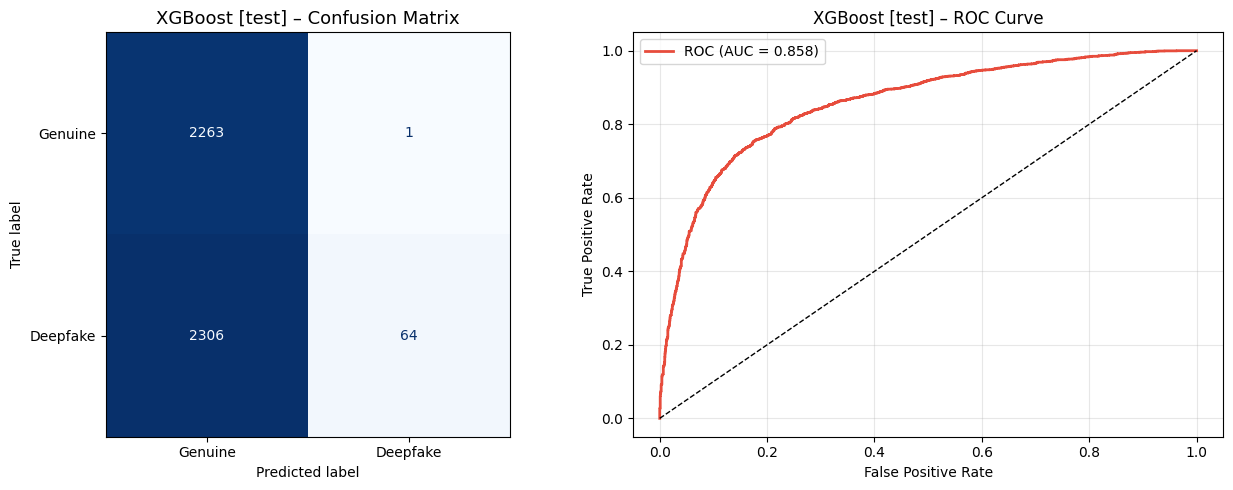

  Saved: ./outputs/XGBoost_[test]_evaluation.png


In [10]:
val_results  = [r for r in all_metrics if "[val]" in r["model"]]
best_ml_name = max(val_results, key=lambda r: r["accuracy"])["model"].replace(" [val]", "")
best_ml      = ml_models[best_ml_name]
print(f"Best ML model on val: {best_ml_name} → evaluating on test set")

y_pred_test  = best_ml.predict(X_test_ml_s)
y_score_test = best_ml.predict_proba(X_test_ml_s)[:, 1]
test_metrics = full_evaluation(y_test, y_pred_test, y_score_test,
                               CFG["class_names"], f"{best_ml_name} [test]",
                               CFG["output_dir"])
all_metrics.append(test_metrics)

In [11]:
T = CFG["n_samples"] // CFG["hop_length"]  # 48000 // 160 = 300 — full 3-sec clip
print(f"DL time frames T = {T}  ({T * CFG['hop_length'] / CFG['sr']:.1f} s)")  # time frames (~0.96 s at hop=160; covers our 3-sec padded clips with plenty of context)

print("Extracting MFCC sequences for DL ...")
def spec_augment(mfcc: np.ndarray,
                 freq_mask_max: int = 6,
                 time_mask_max: int = 25,
                 num_freq_masks: int = 2,
                 num_time_masks: int = 2) -> np.ndarray:
    """SpecAugment: frequency + time masking on MFCC (n_mfcc, T)."""
    mfcc = mfcc.copy()
    n_freq, T = mfcc.shape
    for _ in range(num_freq_masks):
        f  = np.random.randint(1, freq_mask_max + 1)
        f0 = np.random.randint(0, max(1, n_freq - f))
        mfcc[f0:f0 + f, :] = 0.0
    for _ in range(num_time_masks):
        t  = np.random.randint(1, time_mask_max + 1)
        t0 = np.random.randint(0, max(1, T - t))
        mfcc[:, t0:t0 + t] = 0.0
    return mfcc

# REPLACE the existing batch_extract_sequences definition with:
def batch_extract_sequences(audio_list, cfg, T, augment=False):
    seqs = []
    for y in tqdm(audio_list, desc="  MFCC sequences"):
        mfcc = extract_mfcc_sequence(y, cfg, T=T)   # shape: (n_mfcc, T)
        if augment:
            mfcc = spec_augment(mfcc)
        seqs.append(mfcc)
    return np.array(seqs)


X_train_dl = batch_extract_sequences(train_audio, CFG, T, augment=False)   # augmented ← only train
X_val_dl   = batch_extract_sequences(val_audio,   CFG, T, augment=False)  # clean
X_test_dl  = batch_extract_sequences(test_audio,  CFG, T, augment=False)  # clean
# Conv1D expects (batch, timesteps, channels) → transpose from (n_mfcc, T) to (T, n_mfcc)
X_train_dl = X_train_dl.transpose(0, 2, 1)   # (N, T, n_mfcc)
X_val_dl   = X_val_dl.transpose(0, 2, 1)
X_test_dl  = X_test_dl.transpose(0, 2, 1)

print(f"\nDL tensor shapes:")
print(f"  Train : {X_train_dl.shape}")
print(f"  Val   : {X_val_dl.shape}")
print(f"  Test  : {X_test_dl.shape}")

# One-hot labels for Keras
y_train_oh = to_categorical(y_train, num_classes=2)
y_val_oh   = to_categorical(y_val,   num_classes=2)
y_test_oh  = to_categorical(y_test,  num_classes=2)

DL time frames T = 300  (3.0 s)
Extracting MFCC sequences for DL ...


  MFCC sequences: 100%|██████████| 4634/4634 [00:24<00:00, 185.55it/s]



DL tensor shapes:
  Train : (53868, 300, 40)
  Val   : (10798, 300, 40)
  Test  : (4634, 300, 40)


In [12]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    SeparableConv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam


def build_1d_cnn(input_shape: tuple, n_classes: int = 2) -> tf.keras.Model:
    """
    Lightweight 1D CNN for MFCC sequence classification.
    Input shape: (300, 40)
    """

    inp = Input(shape=input_shape, name="mfcc_input")

    # Block 1
    x = SeparableConv1D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="conv1"
    )(inp)

    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Block 2
    x = SeparableConv1D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="conv2"
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Block 3
    x = SeparableConv1D(
        128,
        kernel_size=3,
        padding="same",
        activation="relu",
        name="conv3"
    )(x)

    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # Aggregation
    x = GlobalAveragePooling1D()(x)

    # Classifier Head
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.4)(x)

    out = Dense(
        n_classes,
        activation="softmax",
        name="output"
    )(x)

    model = Model(
        inputs=inp,
        outputs=out,
        name="DeepfakeAudio_1DCNN_Lite"
    )

    return model


cnn_model = build_1d_cnn(
    input_shape=(X_train_dl.shape[1], X_train_dl.shape[2])
)

cnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

print(f"\nTotal parameters: {cnn_model.count_params():,}")

I0000 00:00:1781163571.322156      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13737 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781163571.327261      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "DeepfakeAudio_1DCNN_Lite"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 300, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (SeparableConv1D)         │ (None, 300, 32)        │         1,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (SeparableConv1D)         │ (None, 150, 64)        │         2,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (SeparableConv1D)         │ (None, 75, 128)        │         8,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,434 (83.73 KB)

 Trainable params: 20,986 (81.98 KB)

 Non-trainable params: 448 (1.75 KB)


Total parameters: 21,434


In [13]:
# ── Stochastic SpecAugment via tf.data ────────────────────────
# Augmentation is now applied randomly at each epoch, not once.

def augment_fn(mfcc, label):
    """Apply random SpecAugment mask on the fly during training."""
    def _aug(x):
        x = x.numpy()
        return spec_augment(
            x,
            freq_mask_max=6,
            time_mask_max=30,
            num_freq_masks=2,
            num_time_masks=2
        ).astype(np.float32)

    mfcc = tf.py_function(_aug, [mfcc], tf.float32)
    mfcc.set_shape(X_train_dl.shape[1:])   # restore static shape for Keras
    return mfcc, label


BUFFER  = len(X_train_dl)
BSIZE   = CFG["dl_batch_size"]

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_dl, y_train_oh))
    .shuffle(buffer_size=BUFFER, seed=42, reshuffle_each_iteration=True)
    .map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BSIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_dl, y_val_oh))
    .batch(BSIZE)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_dl, y_test_oh))
    .batch(BSIZE)
    .prefetch(tf.data.AUTOTUNE)
)
print("✅ tf.data pipelines ready — augmentation is now stochastic per epoch.")

✅ tf.data pipelines ready — augmentation is now stochastic per epoch.


In [16]:
cnn_ckpt_path = os.path.join(CFG["output_dir"], "best_1dcnn.keras")

callbacks = [
    ModelCheckpoint(
        cnn_ckpt_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=CFG["dl_patience"],
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG["dl_epochs"],
    # batch_size=CFG["dl_batch_size"],
    callbacks=callbacks,
    verbose=1
)

print(f"\n✅ Training done. Best model saved to: {cnn_ckpt_path}")

Epoch 1/50


I0000 00:00:1781163677.663016     270 service.cc:152] XLA service 0x7a0afc009270 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781163677.663059     270 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781163677.663065     270 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781163678.696886     270 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781163686.705934     270 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8404 - loss: 0.3517
Epoch 1: val_accuracy improved from None to 0.96981, saving model to ./outputs/best_1dcnn.keras

Epoch 1: finished saving model to ./outputs/best_1dcnn.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 88s 43ms/step - accuracy: 0.8843 - loss: 0.2724 - val_accuracy: 0.9698 - val_loss: 0.0811 - learning_rate: 0.0010
Epoch 2/50
1683/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9320 - loss: 0.1716
Epoch 2: val_accuracy improved from 0.96981 to 0.97138, saving model to ./outputs/best_1dcnn.keras

Epoch 2: finished saving model to ./outputs/best_1dcnn.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9370 - loss: 0.1618 - val_accuracy: 0.9714 - val_loss: 0.0745 - learning_rate: 0.0010
Epoch 3/50
1683/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9478 - loss: 0.1373
Epoch 3: val_accuracy improved from 0.97138 to 0.98555, saving model to ./outputs/best_1dcnn.keras

Epoch 3: finished saving model to .

KeyboardInterrupt: 

In [46]:
class SumPool1D(tf.keras.layers.Layer):
    """Replaces Lambda(lambda z: tf.reduce_sum(z, axis=1))"""
    def call(self, x):
        return tf.reduce_sum(x, axis=1)
    
    def get_config(self):          # needed for save/load
        return super().get_config()

In [47]:
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dropout, Bidirectional, LSTM, Dense,
    Softmax, Multiply, Lambda
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf


def build_bilstm_attention(input_shape: tuple, n_classes: int = 2) -> tf.keras.Model:
    """
    BiLSTM with self-attention pooling.
    Input shape: (T, n_mfcc)
    """

    inp = Input(shape=input_shape, name="mfcc_input")

    # CNN front-end
    x = Conv1D(64, kernel_size=5, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=4)(x)
    x = Dropout(0.2)(x)

    # BiLSTM 1
    x = Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.1
        )
    )(x)
    x = BatchNormalization()(x)

    # BiLSTM 2
    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.1
        )
    )(x)
    x = BatchNormalization()(x)

    # ==========================================================
    # Self-Attention Pooling
    # x shape = (batch, T, 128)
    # ==========================================================

    attn_scores = Dense(
        1,
        activation="tanh",
        name="attn_score"
    )(x)                              # (batch, T, 1)

    attn_weights = Softmax(
        axis=1,
        name="attn_weights"
    )(attn_scores)                    # (batch, T, 1)

    weighted_seq = Multiply()(
        [x, attn_weights]
    )    
    # (batch, T, 128)

    x = SumPool1D(name="attention_pooling")(x)                    # (batch, 128)

    # Classifier
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)

    out = Dense(
        n_classes,
        activation="softmax",
        name="output"
    )(x)

    return Model(
        inputs=inp,
        outputs=out,
        name="BiLSTM_Attention"
    )


bilstm_model = build_bilstm_attention(
    input_shape=(X_train_dl.shape[1], X_train_dl.shape[2])
)

bilstm_model.compile(
    optimizer=Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()
print(f"\nTotal parameters: {bilstm_model.count_params():,}")

Model: "BiLSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 300, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 300, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 300, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 75, 256)        │       197,632 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 75, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 75, 128)        │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling (SumPool1D)   │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,538 (1.53 MB)

 Trainable params: 400,642 (1.53 MB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 401,538


In [48]:
bilstm_ckpt = os.path.join(CFG["output_dir"], "best_bilstm.keras")

bilstm_callbacks = [
    ModelCheckpoint(bilstm_ckpt, monitor="val_accuracy",
                    save_best_only=True, mode="max", verbose=1),
    EarlyStopping(monitor="val_loss", patience=CFG["dl_patience"],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

history_bilstm = bilstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG["dl_epochs"],
    callbacks=bilstm_callbacks,
    verbose=1
)
plot_training_history(history_bilstm, "BiLSTM-Attention", CFG["output_dir"])
print(f"\n✅ BiLSTM training done. Best saved to: {bilstm_ckpt}")

Epoch 1/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7471 - loss: 4.4757
Epoch 1: val_accuracy improved from None to 0.93064, saving model to ./outputs/best_bilstm.keras

Epoch 1: finished saving model to ./outputs/best_bilstm.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 1232s 724ms/step - accuracy: 0.7965 - loss: 1.5289 - val_accuracy: 0.9306 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 2/50
  21/1684 ━━━━━━━━━━━━━━━━━━━━ 19:40 710ms/step - accuracy: 0.8193 - loss: 0.3573

KeyboardInterrupt: 

In [44]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MODEL 3 — CNN-BiLSTM Hybrid  ← RECOMMENDED
#
# CNN blocks extract local spectral artifacts (compression, vocoder glitches).
# BiLSTM captures the temporal flow of those artifacts across the clip.
# This combination consistently outperforms either branch alone on deepfake audio.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from tensorflow.keras.layers import SeparableConv1D

def build_cnn_bilstm(input_shape: tuple, n_classes: int = 2) -> tf.keras.Model:
    """
    CNN-BiLSTM Hybrid for deepfake audio detection.
    CNN front-end extracts local patterns → BiLSTM models temporal context.
    Input shape: (T, n_mfcc)
    """
    inp = Input(shape=input_shape, name="mfcc_input")

    # ── CNN front-end ─────────────────────────────────────────
    # Block 1: fine-grained local features
    x = SeparableConv1D(64,  kernel_size=5, padding="same", activation="relu")(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)   # T: 300 → 150
    x = Dropout(0.2)(x)

    # Block 2: larger receptive field
    x = SeparableConv1D(128, kernel_size=5, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)   # T: 150 → 75
    x = Dropout(0.2)(x)

    # Block 3: deep features, no pooling — keep temporal resolution for LSTM
    x = SeparableConv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.15)(x)

    # ── BiLSTM back-end ───────────────────────────────────────
    # Now sequence length = 75: manageable for LSTM, retains enough context
    x = Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.2, recurrent_dropout=0.1))(x)
    x = BatchNormalization()(x)

    # Final LSTM — return only the last state
    x = Bidirectional(LSTM(32, return_sequences=False,
                           dropout=0.2, recurrent_dropout=0.1))(x)

    # ── Classifier ────────────────────────────────────────────
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.4)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.3)(x)
    out = Dense(n_classes, activation="softmax", name="output")(x)

    return tf.keras.Model(inputs=inp, outputs=out, name="CNN_BiLSTM_Hybrid")


hybrid_model = build_cnn_bilstm(
    input_shape=(X_train_dl.shape[1], X_train_dl.shape[2])
)

hybrid_model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hybrid_model.summary()
print(f"\nTotal parameters: {hybrid_model.count_params():,}")

Model: "CNN_BiLSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_input (InputLayer)         │ (None, 300, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_3              │ (None, 300, 64)        │         2,824 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 300, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_4              │ (None, 150, 128)       │         8,640 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 150, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_10 (MaxPooling1D) │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_5              │ (None, 75, 128)        │        16,896 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 75, 128)        │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 64)             │        41,216 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 186,890 (730.04 KB)

 Trainable params: 185,994 (726.54 KB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 186,890


In [31]:
hybrid_ckpt = os.path.join(CFG["output_dir"], "best_hybrid.keras")

hybrid_callbacks = [
    ModelCheckpoint(hybrid_ckpt, monitor="val_accuracy", 
                    save_best_only=True, mode="max", verbose=1),
    EarlyStopping(monitor="val_loss", patience=CFG["dl_patience"],
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
]

history_hybrid = hybrid_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG["dl_epochs"],
    callbacks=hybrid_callbacks,
    verbose=1
)
plot_training_history(history_hybrid, "CNN-BiLSTM-Hybrid", CFG["output_dir"])
print(f"\n✅ Hybrid training done. Best saved to: {hybrid_ckpt}")

Epoch 1/50
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.8226 - loss: 0.4043
Epoch 1: val_accuracy improved from None to 0.96055, saving model to ./outputs/best_hybrid.keras

Epoch 1: finished saving model to ./outputs/best_hybrid.keras
1684/1684 ━━━━━━━━━━━━━━━━━━━━ 1218s 723ms/step - accuracy: 0.8653 - loss: 0.3238 - val_accuracy: 0.9605 - val_loss: 0.1064 - learning_rate: 0.0010
Epoch 2/50
  51/1684 ━━━━━━━━━━━━━━━━━━━━ 19:01 699ms/step - accuracy: 0.9194 - loss: 0.2027

KeyboardInterrupt: 

In [55]:
import keras

@keras.saving.register_keras_serializable()
class SumPool1D(keras.layers.Layer):
    def call(self, x):
        return keras.ops.sum(x, axis=1)   # keras.ops instead of tf.reduce_sum
    def get_config(self):
        return super().get_config()

# Then load:
_custom = {"SumPool1D": SumPool1D}
best_cnn    = load_model(cnn_ckpt_path)
best_bilstm = load_model(bilstm_ckpt,  custom_objects=_custom)
best_hybrid = load_model(hybrid_ckpt,  custom_objects=_custom)


  1D-CNN  – Evaluation Summary
  Overall Accuracy      : 82.61%  (need ≥ 80%)
  F1 Score (binary)     : 80.00%  (need ≥ 80%)
  EER                   : 9.84%  (need ≤ 12%)
  EER threshold         : 0.0242
  ROC-AUC               : 0.9594
  Per-class [Genuine  ]: 97.88%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 68.02%  ❌ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


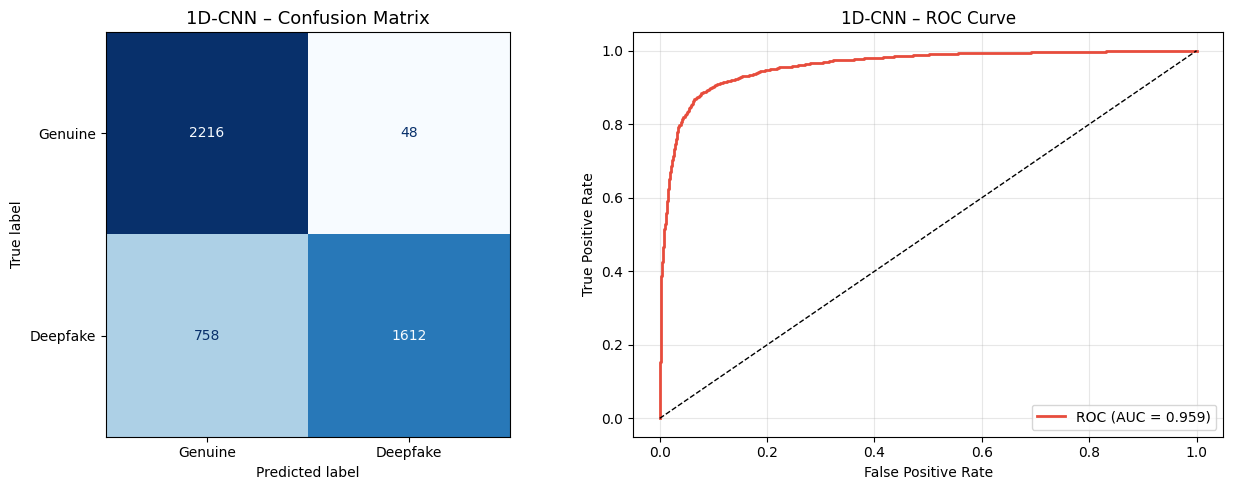

  Saved: ./outputs/1D-CNN_evaluation.png

  BiLSTM-Attention  – Evaluation Summary
  Overall Accuracy      : 80.45%  (need ≥ 80%)
  F1 Score (binary)     : 83.44%  (need ≥ 80%)
  EER                   : 13.12%  (need ≤ 12%)
  EER threshold         : 0.8604
  ROC-AUC               : 0.9382
  Per-class [Genuine  ]: 63.83%  ❌ (need ≥ 75%)
  Per-class [Deepfake ]: 96.33%  ✅ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ❌ FAIL
  [F1  ≥ 80%]  ✅ PASS


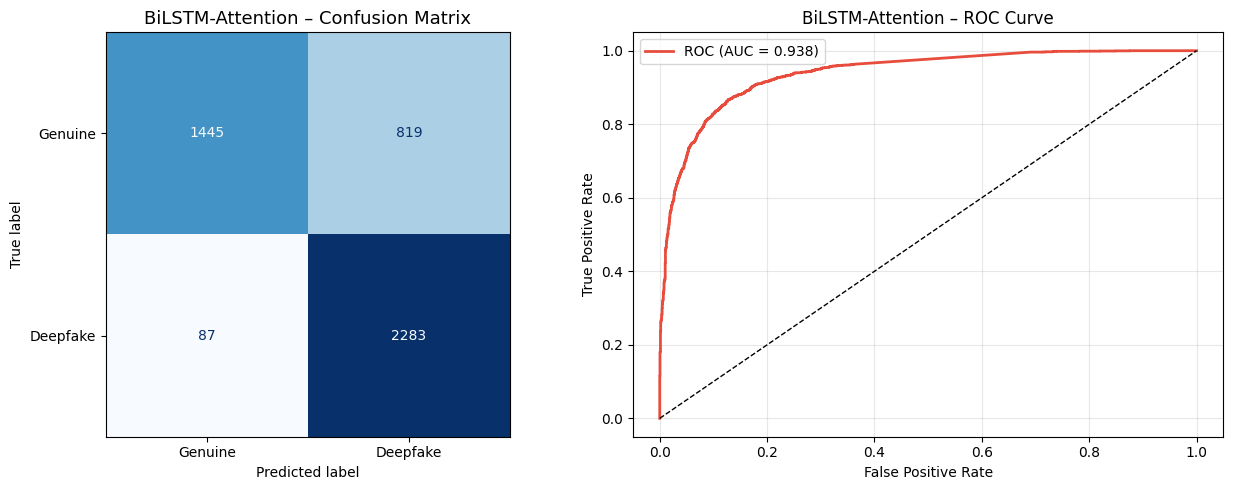

  Saved: ./outputs/BiLSTM-Attention_evaluation.png

  CNN-BiLSTM  – Evaluation Summary
  Overall Accuracy      : 89.19%  (need ≥ 80%)
  F1 Score (binary)     : 89.96%  (need ≥ 80%)
  EER                   : 9.52%  (need ≤ 12%)
  EER threshold         : 0.9168
  ROC-AUC               : 0.9620
  Per-class [Genuine  ]: 83.44%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 94.68%  ✅ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


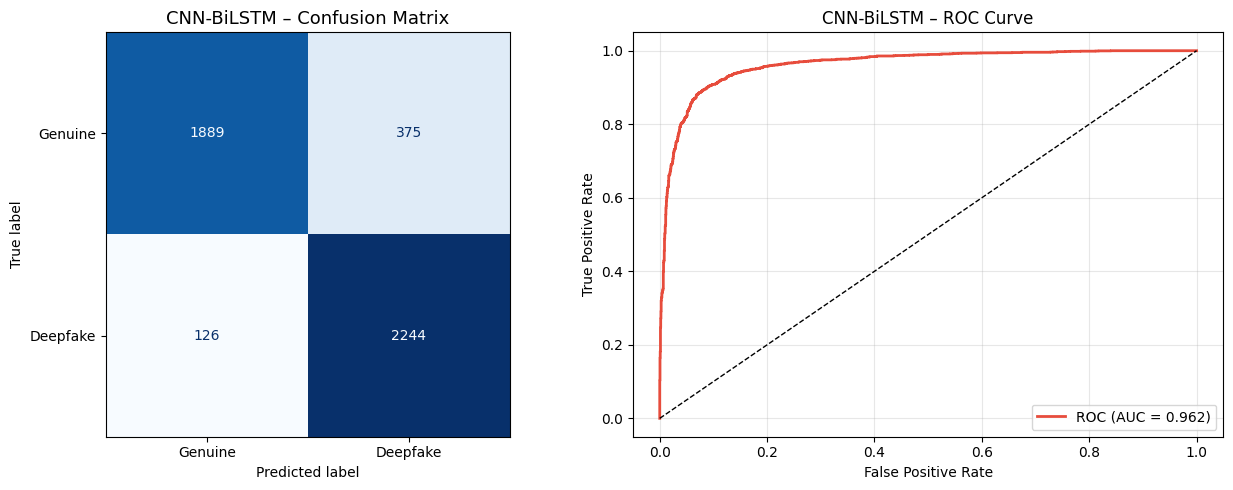

  Saved: ./outputs/CNN-BiLSTM_evaluation.png

  ENSEMBLE — Soft Voting (average of 3 models)

  Ensemble (3-model)  – Evaluation Summary
  Overall Accuracy      : 91.13%  (need ≥ 80%)
  F1 Score (binary)     : 91.61%  (need ≥ 80%)
  EER                   : 7.83%  (need ≤ 12%)
  EER threshold         : 0.6085
  ROC-AUC               : 0.9730
  Per-class [Genuine  ]: 87.41%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 94.68%  ✅ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


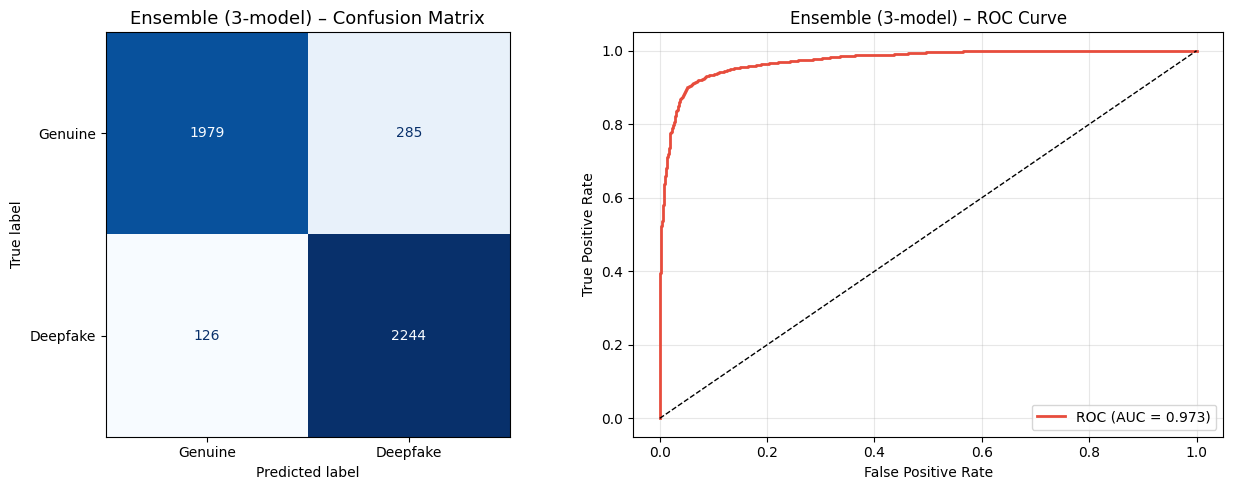

  Saved: ./outputs/Ensemble_(3-model)_evaluation.png

📋 ALL MODELS COMPARISON:


,accuracy,f1,eer,roc_auc
model,,,,
RandomForest [val],99.74,99.74,0.19,1.00
XGBoost [val],99.82,99.82,0.13,1.00
XGBoost [test],50.22,5.26,21.34,0.86
1D-CNN,82.61,80.00,9.84,0.96
1D-CNN,82.61,80.00,9.84,0.96
1D-CNN,82.61,80.00,9.84,0.96
1D-CNN,82.61,80.00,9.84,0.96
BiLSTM-Attention,80.45,83.44,13.12,0.94
CNN-BiLSTM,89.19,89.96,9.52,0.96


In [56]:
# # ── Load best checkpoints ──────────────────────────────────────
# from tensorflow.keras.models import load_model


# best_cnn    = load_model(cnn_ckpt_path)
# best_bilstm = load_model(bilstm_ckpt)
# best_hybrid = load_model(hybrid_ckpt)

dl_models = {
    "1D-CNN":           best_cnn,
    "BiLSTM-Attention": best_bilstm,
    "CNN-BiLSTM":       best_hybrid,
}

# ── Evaluate each individually ────────────────────────────────
for name, model in dl_models.items():
    # Get val probabilities for threshold tuning
    val_probs  = model.predict(X_val_dl,  verbose=0)[:, 1]
    test_probs = model.predict(X_test_dl, verbose=0)[:, 1]

    # Pick threshold on val set (no data leak)
    thrs = np.linspace(0.2, 0.8, 121)
    best_t = float(max(thrs,
                       key=lambda t: f1_score(y_val, (val_probs >= t).astype(int))))

    y_pred_t = (test_probs >= best_t).astype(int)
    metrics  = full_evaluation(y_test, y_pred_t, test_probs,
                               CFG["class_names"], name, CFG["output_dir"])
    all_metrics.append(metrics)

# ── Soft-voting ensemble (average probabilities) ──────────────
print("\n" + "="*55)
print("  ENSEMBLE — Soft Voting (average of 3 models)")
print("="*55)

ensemble_probs = np.mean(
    [m.predict(X_test_dl, verbose=0)[:, 1] for m in dl_models.values()],
    axis=0
)

# Threshold on val ensemble
ensemble_val_probs = np.mean(
    [m.predict(X_val_dl, verbose=0)[:, 1] for m in dl_models.values()],
    axis=0
)
thrs = np.linspace(0.2, 0.8, 121)
best_ensemble_t = float(max(thrs,
    key=lambda t: f1_score(y_val, (ensemble_val_probs >= t).astype(int))))

y_pred_ensemble = (ensemble_probs >= best_ensemble_t).astype(int)
ensemble_metrics = full_evaluation(
    y_test, y_pred_ensemble, ensemble_probs,
    CFG["class_names"], "Ensemble (3-model)", CFG["output_dir"]
)
all_metrics.append(ensemble_metrics)

# ── Final comparison table ─────────────────────────────────────
results_all = pd.DataFrame(all_metrics).set_index("model")
print("\n📋 ALL MODELS COMPARISON:")
display(results_all[["accuracy","f1","eer","roc_auc"]].round(2))

In [58]:
from tensorflow.keras.layers import Average
from tensorflow.keras import Input, Model

# Freeze the sub-models so weights don't accidentally change
for m in [best_cnn, best_bilstm, best_hybrid]:
    m.trainable = False

inp = Input(shape=(X_train_dl.shape[1], X_train_dl.shape[2]), name="ensemble_input")

# Each sub-model returns (batch, 2); take P(fake) column → (batch, 1)
p_cnn    = best_cnn(inp)[:, 1:]
p_bilstm = best_bilstm(inp)[:, 1:]
p_hybrid = best_hybrid(inp)[:, 1:]

avg_prob = Average(name="soft_vote")([p_cnn, p_bilstm, p_hybrid])  # (batch, 1)

ensemble_keras = Model(inputs=inp, outputs=avg_prob, name="Ensemble_SoftVote")

# Verify it matches your earlier ensemble_probs exactly
test_check = ensemble_keras.predict(X_test_dl, verbose=0).ravel()
assert np.allclose(test_check, ensemble_probs, atol=1e-5), "Mismatch — check sub-model order"
print("✅ Ensemble output verified")

# Save
ensemble_path = os.path.join(CFG["output_dir"], "ensemble_softvote.keras")
ensemble_keras.save(ensemble_path)
print(f"✅ Ensemble saved → {ensemble_path}")

# Also save the best threshold
import json
meta = {"best_threshold": best_ensemble_t, "input_shape": list(X_train_dl.shape[1:])}
with open(os.path.join(CFG["output_dir"], "ensemble_meta.json"), "w") as f:
    json.dump(meta, f, indent=2)
print(f"✅ Threshold ({best_ensemble_t:.4f}) saved → ensemble_meta.json")

✅ Ensemble output verified
✅ Ensemble saved → ./outputs/ensemble_softvote.keras
✅ Threshold (0.5350) saved → ensemble_meta.json


  Optimal threshold (val F1): 0.78

  1D-CNN  – Evaluation Summary
  Overall Accuracy      : 82.61%  (need ≥ 80%)
  F1 Score (binary)     : 80.00%  (need ≥ 80%)
  EER                   : 9.84%  (need ≤ 12%)
  EER threshold         : 0.0242
  ROC-AUC               : 0.9594
  Per-class [Genuine  ]: 97.88%  ✅ (need ≥ 75%)
  Per-class [Deepfake ]: 68.02%  ❌ (need ≥ 75%)

  [Acc ≥ 80%]  ✅ PASS
  [EER ≤ 12%]  ✅ PASS
  [F1  ≥ 80%]  ✅ PASS


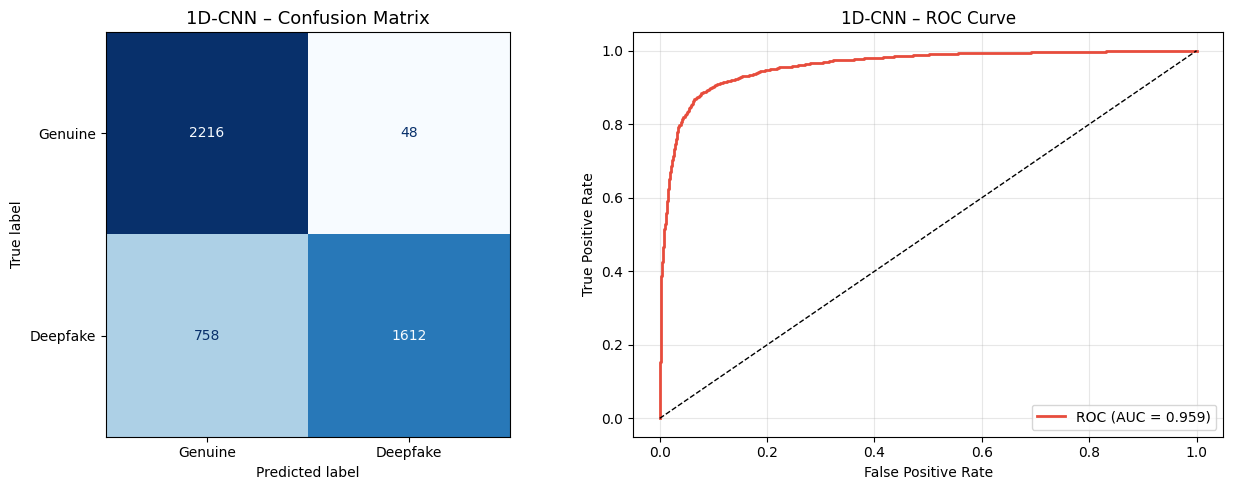

  Saved: ./outputs/1D-CNN_evaluation.png


In [24]:

# Load the checkpoint with best val_accuracy
best_cnn = load_model(cnn_ckpt_path)

y_score_cnn = best_cnn.predict(X_test_dl, verbose=0)[:, 1]  # P(fake)
_val_scores = best_cnn.predict(X_val_dl, verbose=0)[:, 1]
_thresholds = np.linspace(0.2, 0.8, 121)
best_thr = float(max(_thresholds,
                     key=lambda t: f1_score(y_val, (_val_scores >= t).astype(int))))
print(f"  Optimal threshold (val F1): {best_thr:.2f}")
y_pred_cnn = (y_score_cnn >= best_thr).astype(int)

cnn_metrics = full_evaluation(
    y_test, y_pred_cnn, y_score_cnn,
    CFG["class_names"], "1D-CNN", CFG["output_dir"]
)
all_metrics.append(cnn_metrics)


In [1]:
# def predict_audio(audio_path: str, dl_model, scaler,
#                   ml_model=None, cfg: dict = CFG) -> dict:
#     """
#     Predict whether a single audio file is Genuine or Deepfake.
#     Returns a dict with label, confidence, and per-model probabilities.
#     """
#     print(f"\n🔍 Analysing: {os.path.basename(audio_path)}")

#     # Load & preprocess
#     y = load_audio(audio_path, sr=cfg["sr"], n_samples=cfg["n_samples"])
#     if y is None:
#         return {"error": "Could not load audio file"}

#     results = {}

#     # ── 1D-CNN prediction ──────────────────────────────────────
#     T_infer = cfg["n_samples"] // cfg["hop_length"]
#     seq = extract_mfcc_sequence(y, cfg, T=T_infer)          # (n_mfcc, T)
#     seq = seq.T[np.newaxis, ...]                        # (1, T, n_mfcc)
#     cnn_proba = dl_model.predict(seq, verbose=0)[0]     # [P(real), P(fake)]
#     cnn_label = int(np.argmax(cnn_proba))
#     results["1D-CNN"] = {
#         "label":      cfg["class_names"][cnn_label],
#         "P(Genuine)": float(cnn_proba[0]),
#         "P(Deepfake)": float(cnn_proba[1]),
#     }

#     # ── ML model prediction (optional) ────────────────────────
#     if ml_model is not None:
#         fvec  = extract_feature_vector(y, cfg).reshape(1, -1)
#         fvec  = scaler.transform(fvec)
#         ml_proba = ml_model.predict_proba(fvec)[0]
#         ml_label = int(np.argmax(ml_proba))
#         ml_name  = type(ml_model).__name__
#         results[ml_name] = {
#             "label":       cfg["class_names"][ml_label],
#             "P(Genuine)":  float(ml_proba[0]),
#             "P(Deepfake)": float(ml_proba[1]),
#         }

#     # ── Print ──────────────────────────────────────────────────
#     for model_name, res in results.items():
#         print(f"  [{model_name}]  → {res['label']}  "
#               f"(Genuine: {res['P(Genuine)']:.1%}  |  Deepfake: {res['P(Deepfake)']:.1%})")

#     return results


# ── Example call ───────────────────────────────────────────────
# Change the path below to any .wav file you want to test:
# ── How to find a real filename to test ──────────────────────
# import glob
# files = glob.glob(CFG["test_dir"] + "/fake/*.wav")
# print(files[:3])   # copy one of these paths into AUDIO_PATH below
#
# AUDIO_PATH = "/kaggle/input/the-fake-or-real-dataset/for-norm/for-norm/testing/fake/file10004.wav_16k.wav_norm.wav"
# predict_audio(AUDIO_PATH, best_cnn, scaler, ml_model=ml_models.get("XGBoost"))


In [61]:
final_cnn_path = os.path.join(CFG["output_dir"], "final_1dcnn.keras")
best_cnn.save(final_cnn_path)
print(f"✅ DL model saved  → {final_cnn_path}")

print(f"✅ Scaler saved    → {os.path.join(CFG['output_dir'], 'feature_scaler.pkl')}")

for name in ml_models:
    p = os.path.join(CFG["output_dir"], f"{name.replace(' ','_')}_model.pkl")
    exists = "✅" if os.path.exists(p) else "❌"
    print(f"{exists} ML model saved  → {p}")

print("\n" + "="*65)
print("  📄 FINAL PERFORMANCE REPORT")
print("="*65)
display(results_all[["accuracy","f1","eer","roc_auc",
                      "acc_Genuine","acc_Deepfake","threshold"]].round(3))
print("\nAll outputs are in:", CFG["output_dir"])
print("\n" + "="*65)

✅ DL model saved  → ./outputs/final_1dcnn.keras
✅ Scaler saved    → ./outputs/feature_scaler.pkl
✅ ML model saved  → ./outputs/RandomForest_model.pkl
✅ ML model saved  → ./outputs/XGBoost_model.pkl

  📄 FINAL PERFORMANCE REPORT


,accuracy,f1,eer,roc_auc,acc_Genuine,acc_Deepfake,threshold
model,,,,,,,
RandomForest [val],99.741,99.741,0.185,1.000,99.537,99.944,0.613
XGBoost [val],99.824,99.824,0.130,1.000,99.741,99.907,0.650
XGBoost [test],50.216,5.257,21.342,0.858,99.956,2.700,0.000
1D-CNN,82.607,80.000,9.841,0.959,97.880,68.017,0.024
1D-CNN,82.607,80.000,9.841,0.959,97.880,68.017,0.024
1D-CNN,82.607,80.000,9.841,0.959,97.880,68.017,0.024
1D-CNN,82.607,80.000,9.841,0.959,97.880,68.017,0.024
BiLSTM-Attention,80.449,83.443,13.120,0.938,63.825,96.329,0.860
CNN-BiLSTM,89.189,89.958,9.516,0.962,83.436,94.684,0.917



All outputs are in: ./outputs

